In [ ]:

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

In [ ]:
# 스키마 — 카테고리 + 개선 제안 추가
class ReviewFull(BaseModel):
    rating: int = Field(description="평점 1-5점", ge=1, le=5)
    sentiment: Literal["positive", "negative", "neutral"] = Field(description="감정")
    category: Literal["품질", "가격", "배송", "디자인", "기타"] = Field(description="리뷰가 다루는 영역")
    keywords: list[str] = Field(description="핵심 키워드 3개")
    improvement: Optional[str] = Field(default=None, description="개선 제안 (있으면, 없으면 None)")

parser_r = PydanticOutputParser(pydantic_object=ReviewFull)
prompt_r = ChatPromptTemplate.from_messages([
    ("system", "쇼핑몰 리뷰 분석가입니다. 한국어로 답하세요.\n\n{format_instructions}"),
    ("human", "리뷰: {review}")
]).partial(format_instructions=parser_r.get_format_instructions())

chain_review = prompt_r | llm | parser_r

In [ ]:
# 테스트 — 3개 리뷰
reviews = [
    "포장이 너무 아쉽네요. 박스가 찌그러져 왔어요.",
    "가성비 짱! 이 가격에 이 정도면 최고예요.",
    "디자인은 예쁜데 기능이 좀 부족하네요.",
]

for r in reviews:
    res = chain_review.invoke({"review": r})
    print(f"📝 '{r}'")
    print(f"   ⭐ {res.rating}/5 | {res.sentiment} | 📁 {res.category}")
    print(f"   🏷️  {', '.join(res.keywords)}")
    if res.improvement:
        print(f"   💡 개선: {res.improvement}")
    print()

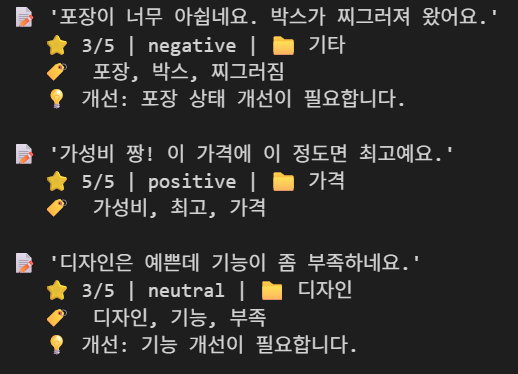